# Day 2 - Session 3: tidyverse Universe
**Duration: ~2-2.5 hours**

## Learning Objectives
- Understand the tidyverse philosophy and ecosystem
- Master dplyr for data manipulation
- Learn tidyr for data reshaping
- Perform grouped operations and summaries
- Conduct exploratory data analysis with tidyverse tools
- Create analysis pipelines

## Part 1: Introduction to the tidyverse

### What is the tidyverse?

The **tidyverse** is a collection of R packages designed for data science. All packages share an underlying design philosophy, grammar, and data structures.

**Core tidyverse packages:**
- **dplyr**: Data manipulation
- **tidyr**: Data tidying
- **ggplot2**: Data visualization (covered yesterday)
- **readr**: Reading data
- **purrr**: Functional programming
- **tibble**: Modern data frames
- **stringr**: String manipulation
- **forcats**: Factor handling

### The tidyverse Philosophy

1. **Reuse existing data structures** (data frames/tibbles)
2. **Compose simple functions with pipes**
3. **Embrace functional programming**
4. **Design for humans**

In [1]:
# Install and load tidyverse
# install.packages("tidyverse")  # Run once

library(tidyverse)  # Loads all core tidyverse packages

# Load sample data
data(starwars)
data(iris)
data(mtcars)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


---

## Part 2: Data Manipulation with dplyr

### 2.1 The Pipe Operator: %>%

The pipe operator is key to readable code. It passes output from one function to the next.

**Think of it as "then":** Take data **then** filter **then** select **then** summarize

**Keyboard shortcut:** Ctrl+Shift+M (Windows/Linux) or Cmd+Shift+M (Mac)

In [2]:
# Without pipe (nested, hard to read)
mean(sqrt(abs(c(-4, -1, 0, 1, 4))))

# With pipe (reads left to right)
c(-4, -1, 0, 1, 4) %>%
  abs() %>%
  sqrt() %>%
  mean()

[1] 1.2

[1] 1.2

### 2.2 The Five Main dplyr Verbs

#### filter() - Keep Rows That Match Conditions

In [3]:
# Filter humans
starwars %>%
  filter(species == "Human") %>%
  head()

# Multiple conditions
starwars %>%
  filter(species == "Human", height > 180) %>%
  select(name, height, species)

# OR condition
starwars %>%
  filter(species %in% c("Human", "Droid", "Wookiee")) %>%
  count(species)

ERROR while rich displaying an object: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 5, 4, 3, 1

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .     

name,height,species
<chr>,<int>,<chr>
Darth Vader,202,Human
Biggs Darklighter,183,Human
Obi-Wan Kenobi,182,Human
Anakin Skywalker,188,Human
Boba Fett,183,Human
Qui-Gon Jinn,193,Human
Padmé Amidala,185,Human
Ric Olié,183,Human
Quarsh Panaka,183,Human


species,n
<chr>,<int>
Droid,6
Human,35
Wookiee,2


#### select() - Choose Columns

In [4]:
# Select specific columns
starwars %>%
  select(name, height, mass) %>%
  head()

# Exclude columns
starwars %>%
  select(-films, -vehicles, -starships) %>%
  head()

# Helper functions
starwars %>%
  select(starts_with("s")) %>%
  head()

name,height,mass
<chr>,<int>,<dbl>
Luke Skywalker,172,77
C-3PO,167,75
R2-D2,96,32
Darth Vader,202,136
Leia Organa,150,49
Owen Lars,178,120


name,height,mass,hair_color,skin_color,eye_color,birth_year,sex,gender,homeworld,species
<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
Luke Skywalker,172,77,blond,fair,blue,19.0,male,masculine,Tatooine,Human
C-3PO,167,75,NA,gold,yellow,112.0,none,masculine,Tatooine,Droid
R2-D2,96,32,NA,"white, blue",red,33.0,none,masculine,Naboo,Droid
Darth Vader,202,136,none,white,yellow,41.9,male,masculine,Tatooine,Human
Leia Organa,150,49,brown,light,brown,19.0,female,feminine,Alderaan,Human
Owen Lars,178,120,"brown, grey",light,blue,52.0,male,masculine,Tatooine,Human


ERROR while rich displaying an object: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 2, 0, 1

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .        

#### mutate() - Create or Modify Columns

In [5]:
# Add BMI column
starwars %>%
  mutate(
    bmi = mass / ((height / 100) ^ 2),
    bmi_category = case_when(
      bmi < 18.5 ~ "Underweight",
      bmi < 25 ~ "Normal",
      bmi < 30 ~ "Overweight",
      TRUE ~ "Obese"
    )
  ) %>%
  select(name, bmi, bmi_category) %>%
  filter(!is.na(bmi)) %>%
  head()

name,bmi,bmi_category
<chr>,<dbl>,<chr>
Luke Skywalker,26.02758,Overweight
C-3PO,26.89232,Overweight
R2-D2,34.72222,Obese
Darth Vader,33.33007,Obese
Leia Organa,21.77778,Normal
Owen Lars,37.87401,Obese


#### arrange() - Sort Rows

In [6]:
# Sort ascending
starwars %>%
  arrange(height) %>%
  select(name, height) %>%
  head()

# Sort descending
starwars %>%
  arrange(desc(height)) %>%
  select(name, height) %>%
  head()

# Multiple columns
starwars %>%
  arrange(species, desc(height)) %>%
  select(name, species, height) %>%
  head(10)

name,height
<chr>,<int>
Yoda,66
Ratts Tyerel,79
Wicket Systri Warrick,88
Dud Bolt,94
R2-D2,96
R4-P17,96


name,height
<chr>,<int>
Yarael Poof,264
Tarfful,234
Lama Su,229
Chewbacca,228
Roos Tarpals,224
Grievous,216


name,species,height
<chr>,<chr>,<int>
Ratts Tyerel,Aleena,79
Dexter Jettster,Besalisk,198
Ki-Adi-Mundi,Cerean,198
Mas Amedda,Chagrian,196
Zam Wesell,Clawdite,168
IG-88,Droid,200
C-3PO,Droid,167
R5-D4,Droid,97
R2-D2,Droid,96


#### summarize() - Calculate Summary Statistics

In [7]:
# Single summary
starwars %>%
  summarize(
    mean_height = mean(height, na.rm = TRUE),
    sd_height = sd(height, na.rm = TRUE)
  )

# Multiple summaries
starwars %>%
  summarize(
    n = n(),
    mean_height = mean(height, na.rm = TRUE),
    median_height = median(height, na.rm = TRUE),
    max_height = max(height, na.rm = TRUE)
  )

mean_height,sd_height
<dbl>,<dbl>
174.6049,34.77416


n,mean_height,median_height,max_height
<int>,<dbl>,<int>,<int>
87,174.6049,180,264


### 2.3 Grouped Operations: The Power of group_by()

**This is where dplyr truly shines!**

In [8]:
# Calculate mean height by species
starwars %>%
  group_by(species) %>%
  summarize(
    count = n(),
    mean_height = mean(height, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_height)) %>%
  head(10)

species,count,mean_height
<chr>,<int>,<dbl>
Quermian,1,264.0000
Wookiee,2,231.0000
Kaminoan,2,221.0000
Kaleesh,1,216.0000
Gungan,3,208.6667
Pau'an,1,206.0000
Besalisk,1,198.0000
Cerean,1,198.0000
Chagrian,1,196.0000


In [9]:
# Multiple grouping variables
starwars %>%
  group_by(species, sex) %>%
  summarize(
    count = n(),
    mean_height = mean(height, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(count > 1) %>%
  arrange(desc(mean_height))

species,sex,count,mean_height
<chr>,<chr>,<int>,<dbl>
Wookiee,male,2,231.0000
Gungan,male,3,208.6667
Human,male,26,182.3913
NA,NA,4,175.0000
Zabrak,male,2,173.0000
Mirialan,female,2,168.0000
Human,female,9,163.5714
Droid,none,6,131.2000


In [10]:
# Using mutate with groups (compare to group average)
starwars %>%
  group_by(species) %>%
  mutate(
    species_mean_height = mean(height, na.rm = TRUE),
    height_diff_from_species_avg = height - species_mean_height
  ) %>%
  ungroup() %>%
  select(name, species, height, height_diff_from_species_avg) %>%
  filter(!is.na(height_diff_from_species_avg)) %>%
  arrange(desc(height_diff_from_species_avg)) %>%
  head(10)

name,species,height,height_diff_from_species_avg
<chr>,<chr>,<int>,<dbl>
IG-88,Droid,200,68.80000
C-3PO,Droid,167,35.80000
Darth Vader,Human,202,24.00000
Roos Tarpals,Gungan,224,15.33333
Qui-Gon Jinn,Human,193,15.00000
Dooku,Human,193,15.00000
Bail Prestor Organa,Human,191,13.00000
Anakin Skywalker,Human,188,10.00000
Mace Windu,Human,188,10.00000


### 2.4 count() - Quick Frequency Tables

In [11]:
# Count by species
starwars %>%
  count(species, sort = TRUE) %>%
  head(10)

# Count by multiple variables
starwars %>%
  count(species, homeworld, sort = TRUE) %>%
  head(10)

# Add proportions
starwars %>%
  count(species) %>%
  mutate(proportion = n / sum(n)) %>%
  arrange(desc(proportion)) %>%
  head(10)

species,n
<chr>,<int>
Human,35
Droid,6
NA,4
Gungan,3
Kaminoan,2
Mirialan,2
Twi'lek,2
Wookiee,2
Zabrak,2


species,homeworld,n
<chr>,<chr>,<int>
Human,Tatooine,8
Human,NA,6
Human,Naboo,5
Droid,NA,3
Gungan,Naboo,3
Human,Alderaan,3
Droid,Tatooine,2
Human,Corellia,2
Human,Coruscant,2


species,n,proportion
<chr>,<int>,<dbl>
Human,35,0.40229885
Droid,6,0.06896552
NA,4,0.04597701
Gungan,3,0.03448276
Kaminoan,2,0.02298851
Mirialan,2,0.02298851
Twi'lek,2,0.02298851
Wookiee,2,0.02298851
Zabrak,2,0.02298851


---

## Part 3: Data Tidying with tidyr

### 3.1 Tidy Data Principles

**Tidy data** has three rules:
1. Each variable is a column
2. Each observation is a row
3. Each value is a cell

### 3.2 pivot_longer() - Wide to Long Format

In [12]:
# Example: Convert iris measurements to long format
iris_long <- iris %>%
  mutate(id = row_number()) %>%
  pivot_longer(
    cols = c(Sepal.Length, Sepal.Width, Petal.Length, Petal.Width),
    names_to = "measurement_type",
    values_to = "value"
  )

head(iris_long, 10)

Species,id,measurement_type,value
<fct>,<int>,<chr>,<dbl>
setosa,1,Sepal.Length,5.1
setosa,1,Sepal.Width,3.5
setosa,1,Petal.Length,1.4
setosa,1,Petal.Width,0.2
setosa,2,Sepal.Length,4.9
setosa,2,Sepal.Width,3.0
setosa,2,Petal.Length,1.4
setosa,2,Petal.Width,0.2
setosa,3,Sepal.Length,4.7


In [13]:
# Separate measurement type into part and dimension
iris_long %>%
  separate(measurement_type, into = c("part", "dimension"), sep = "\\.") %>%
  head(10)

Species,id,part,dimension,value
<fct>,<int>,<chr>,<chr>,<dbl>
setosa,1,Sepal,Length,5.1
setosa,1,Sepal,Width,3.5
setosa,1,Petal,Length,1.4
setosa,1,Petal,Width,0.2
setosa,2,Sepal,Length,4.9
setosa,2,Sepal,Width,3.0
setosa,2,Petal,Length,1.4
setosa,2,Petal,Width,0.2
setosa,3,Sepal,Length,4.7


### 3.3 pivot_wider() - Long to Wide Format

In [14]:
# Example: Reshape back to wide
iris_wide <- iris_long %>%
  pivot_wider(
    names_from = measurement_type,
    values_from = value
  )

head(iris_wide)

Species,id,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
setosa,1,5.1,3.5,1.4,0.2
setosa,2,4.9,3.0,1.4,0.2
setosa,3,4.7,3.2,1.3,0.2
setosa,4,4.6,3.1,1.5,0.2
setosa,5,5.0,3.6,1.4,0.2
setosa,6,5.4,3.9,1.7,0.4


---

## Part 4: Complete Data Analysis Pipeline

Let's combine everything we've learned into a complete analysis.

In [15]:
# Analysis: Fuel efficiency by car characteristics
mtcars_analysis <- mtcars %>%
  # Add rownames as a column
  rownames_to_column(var = "car_model") %>%
  # Create categorical variables
  mutate(
    cyl_category = case_when(
      cyl == 4 ~ "4 cylinder",
      cyl == 6 ~ "6 cylinder",
      cyl == 8 ~ "8 cylinder"
    ),
    transmission = ifelse(am == 0, "automatic", "manual"),
    efficiency = case_when(
      mpg >= 25 ~ "High",
      mpg >= 20 ~ "Medium",
      TRUE ~ "Low"
    )
  ) %>%
  # Select relevant columns
  select(car_model, mpg, cyl_category, transmission, efficiency, wt, hp) %>%
  # Arrange by mpg
  arrange(desc(mpg))

head(mtcars_analysis, 10)

,car_model,mpg,cyl_category,transmission,efficiency,wt,hp
,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,Toyota Corolla,33.9,4 cylinder,manual,High,1.835,65
2,Fiat 128,32.4,4 cylinder,manual,High,2.200,66
3,Honda Civic,30.4,4 cylinder,manual,High,1.615,52
4,Lotus Europa,30.4,4 cylinder,manual,High,1.513,113
5,Fiat X1-9,27.3,4 cylinder,manual,High,1.935,66
6,Porsche 914-2,26.0,4 cylinder,manual,High,2.140,91
7,Merc 240D,24.4,4 cylinder,automatic,Medium,3.190,62
8,Datsun 710,22.8,4 cylinder,manual,Medium,2.320,93
9,Merc 230,22.8,4 cylinder,automatic,Medium,3.150,95


In [16]:
# Summarize by cylinder and transmission
summary_stats <- mtcars_analysis %>%
  group_by(cyl_category, transmission) %>%
  summarize(
    n_cars = n(),
    mean_mpg = round(mean(mpg), 2),
    sd_mpg = round(sd(mpg), 2),
    mean_weight = round(mean(wt), 2),
    mean_hp = round(mean(hp), 1),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_mpg))

print(summary_stats)

# A tibble: 6 × 7
  cyl_category transmission n_cars mean_mpg sd_mpg mean_weight mean_hp
  <chr>        <chr>         <int>    <dbl>  <dbl>       <dbl>   <dbl>
1 4 cylinder   manual            8     28.1   4.48        2.04    81.9
2 4 cylinder   automatic         3     22.9   1.45        2.94    84.7
3 6 cylinder   manual            3     20.6   0.75        2.76   132. 
4 6 cylinder   automatic         4     19.1   1.63        3.39   115. 
5 8 cylinder   manual            2     15.4   0.57        3.37   300. 
6 8 cylinder   automatic        12     15.0   2.77        4.1    194. 


### 4.1 Combining with ggplot2

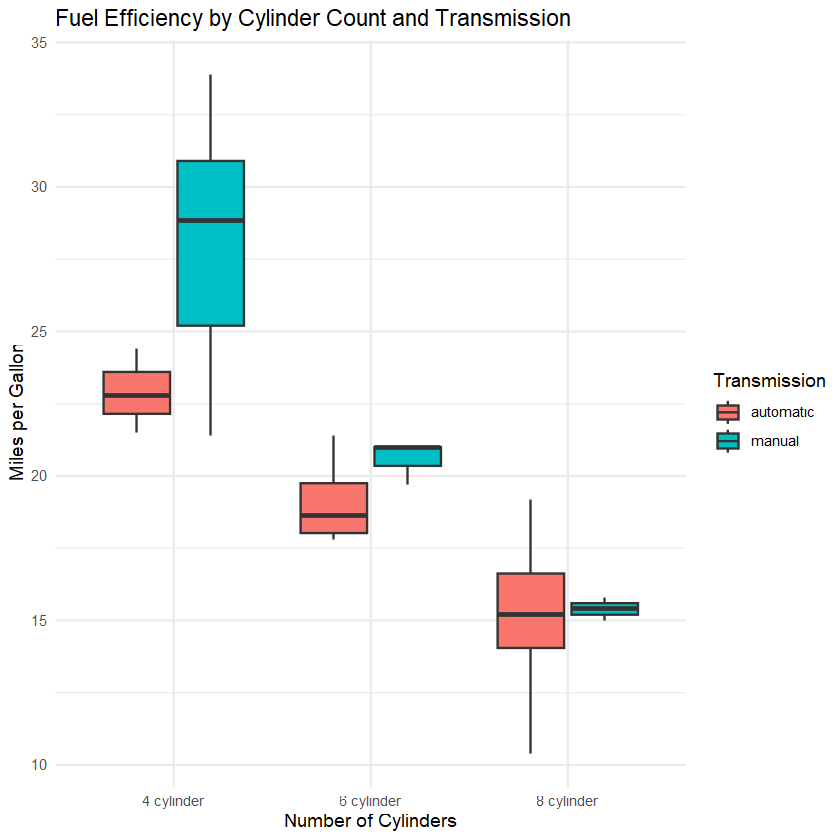

In [17]:
# Visualize the analysis
mtcars_analysis %>%
  ggplot(aes(x = cyl_category, y = mpg, fill = transmission)) +
  geom_boxplot() +
  labs(
    title = "Fuel Efficiency by Cylinder Count and Transmission",
    x = "Number of Cylinders",
    y = "Miles per Gallon",
    fill = "Transmission"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


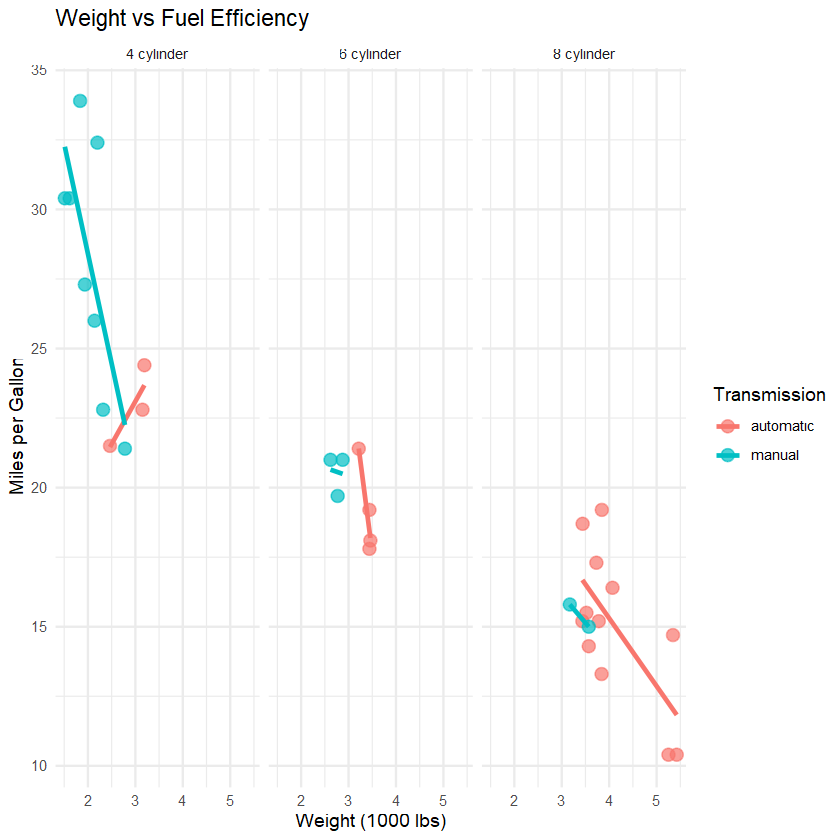

In [18]:
# Faceted analysis
mtcars_analysis %>%
  ggplot(aes(x = wt, y = mpg, color = transmission)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ cyl_category) +
  labs(
    title = "Weight vs Fuel Efficiency",
    x = "Weight (1000 lbs)",
    y = "Miles per Gallon",
    color = "Transmission"
  ) +
  theme_minimal()

---

## Part 5: Advanced dplyr Techniques

### 5.1 across() - Apply Functions to Multiple Columns

In [19]:
# Summarize multiple columns at once
iris %>%
  group_by(Species) %>%
  summarize(
    across(
      c(Sepal.Length, Sepal.Width, Petal.Length, Petal.Width),
      list(mean = mean, sd = sd)
    ),
    .groups = "drop"
  )

Species,Sepal.Length_mean,Sepal.Length_sd,Sepal.Width_mean,Sepal.Width_sd,Petal.Length_mean,Petal.Length_sd,Petal.Width_mean,Petal.Width_sd
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
setosa,5.006,0.3524897,3.428,0.3790644,1.462,0.1736640,0.246,0.1053856
versicolor,5.936,0.5161711,2.770,0.3137983,4.260,0.4699110,1.326,0.1977527
virginica,6.588,0.6358796,2.974,0.3224966,5.552,0.5518947,2.026,0.2746501


### 5.2 case_when() - Multiple Conditions

In [20]:
# Create categories based on multiple conditions
iris %>%
  mutate(
    size_category = case_when(
      Petal.Length < 2 ~ "Small",
      Petal.Length < 5 ~ "Medium",
      TRUE ~ "Large"  # Everything else
    ),
    width_category = case_when(
      Petal.Width < 0.5 ~ "Narrow",
      Petal.Width < 1.5 ~ "Medium",
      TRUE ~ "Wide"
    )
  ) %>%
  count(Species, size_category, width_category)

Species,size_category,width_category,n
<fct>,<chr>,<chr>,<int>
setosa,Small,Medium,2
setosa,Small,Narrow,48
versicolor,Large,Wide,2
versicolor,Medium,Medium,35
versicolor,Medium,Wide,13
virginica,Large,Medium,1
virginica,Large,Wide,43
virginica,Medium,Wide,6


### 5.3 joins - Combining Datasets

In [21]:
# Create example datasets
patients <- tibble(
  patient_id = 1:5,
  name = c("Alice", "Bob", "Charlie", "Diana", "Eve"),
  age = c(45, 32, 56, 28, 41)
)

measurements <- tibble(
  patient_id = c(1, 2, 3, 3, 4, 6),
  measurement = c(7.2, 8.1, 6.5, 7.8, 5.4, 9.0),
  date = c("2024-01-01", "2024-01-02", "2024-01-03", "2024-01-15", "2024-01-04", "2024-01-05")
)

# Inner join (only matching)
inner_join(patients, measurements, by = "patient_id")

patient_id,name,age,measurement,date
<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,Alice,45,7.2,2024-01-01
2,Bob,32,8.1,2024-01-02
3,Charlie,56,6.5,2024-01-03
3,Charlie,56,7.8,2024-01-15
4,Diana,28,5.4,2024-01-04


In [22]:
# Left join (keep all patients)
left_join(patients, measurements, by = "patient_id")

# Right join (keep all measurements)
right_join(patients, measurements, by = "patient_id")

patient_id,name,age,measurement,date
<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,Alice,45,7.2,2024-01-01
2,Bob,32,8.1,2024-01-02
3,Charlie,56,6.5,2024-01-03
3,Charlie,56,7.8,2024-01-15
4,Diana,28,5.4,2024-01-04
5,Eve,41,NA,NA


patient_id,name,age,measurement,date
<dbl>,<chr>,<dbl>,<dbl>,<chr>
1,Alice,45,7.2,2024-01-01
2,Bob,32,8.1,2024-01-02
3,Charlie,56,6.5,2024-01-03
3,Charlie,56,7.8,2024-01-15
4,Diana,28,5.4,2024-01-04
6,NA,NA,9.0,2024-01-05


---

## Part 6: Practical Exploratory Data Analysis

Let's perform a complete exploratory analysis using tidyverse tools.

In [23]:
# Load a dataset
data(mpg)

# 1. Initial exploration
glimpse(mpg)

Rows: 234
Columns: 11
$ manufacturer <chr> "audi", "audi", "audi", "audi", "audi", "audi", "audi", "…
$ model        <chr> "a4", "a4", "a4", "a4", "a4", "a4", "a4", "a4 quattro", "…
$ displ        <dbl> 1.8, 1.8, 2.0, 2.0, 2.8, 2.8, 3.1, 1.8, 1.8, 2.0, 2.0, 2.…
$ year         <int> 1999, 1999, 2008, 2008, 1999, 1999, 2008, 1999, 1999, 200…
$ cyl          <int> 4, 4, 4, 4, 6, 6, 6, 4, 4, 4, 4, 6, 6, 6, 6, 6, 6, 8, 8, …
$ trans        <chr> "auto(l5)", "manual(m5)", "manual(m6)", "auto(av)", "auto…
$ drv          <chr> "f", "f", "f", "f", "f", "f", "f", "4", "4", "4", "4", "4…
$ cty          <int> 18, 21, 20, 21, 16, 18, 18, 18, 16, 20, 19, 15, 17, 17, 1…
$ hwy          <int> 29, 29, 31, 30, 26, 26, 27, 26, 25, 28, 27, 25, 25, 25, 2…
$ fl           <chr> "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p", "p…
$ class        <chr> "compact", "compact", "compact", "compact", "compact", "c…


In [24]:
# 2. Summary statistics
mpg %>%
  summarize(
    n_cars = n(),
    n_manufacturers = n_distinct(manufacturer),
    n_models = n_distinct(model),
    mean_hwy = mean(hwy),
    mean_cty = mean(cty)
  )

n_cars,n_manufacturers,n_models,mean_hwy,mean_cty
<int>,<int>,<int>,<dbl>,<dbl>
234,15,38,23.44017,16.85897


In [25]:
# 3. Group analysis
mpg_by_class <- mpg %>%
  group_by(class) %>%
  summarize(
    count = n(),
    mean_hwy = round(mean(hwy), 1),
    mean_cty = round(mean(cty), 1),
    mean_displ = round(mean(displ), 1),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_hwy))

print(mpg_by_class)

# A tibble: 7 × 5
  class      count mean_hwy mean_cty mean_displ
  <chr>      <int>    <dbl>    <dbl>      <dbl>
1 compact       47     28.3     20.1        2.3
2 subcompact    35     28.1     20.4        2.7
3 midsize       41     27.3     18.8        2.9
4 2seater        5     24.8     15.4        6.2
5 minivan       11     22.4     15.8        3.4
6 suv           62     18.1     13.5        4.5
7 pickup        33     16.9     13          4.4


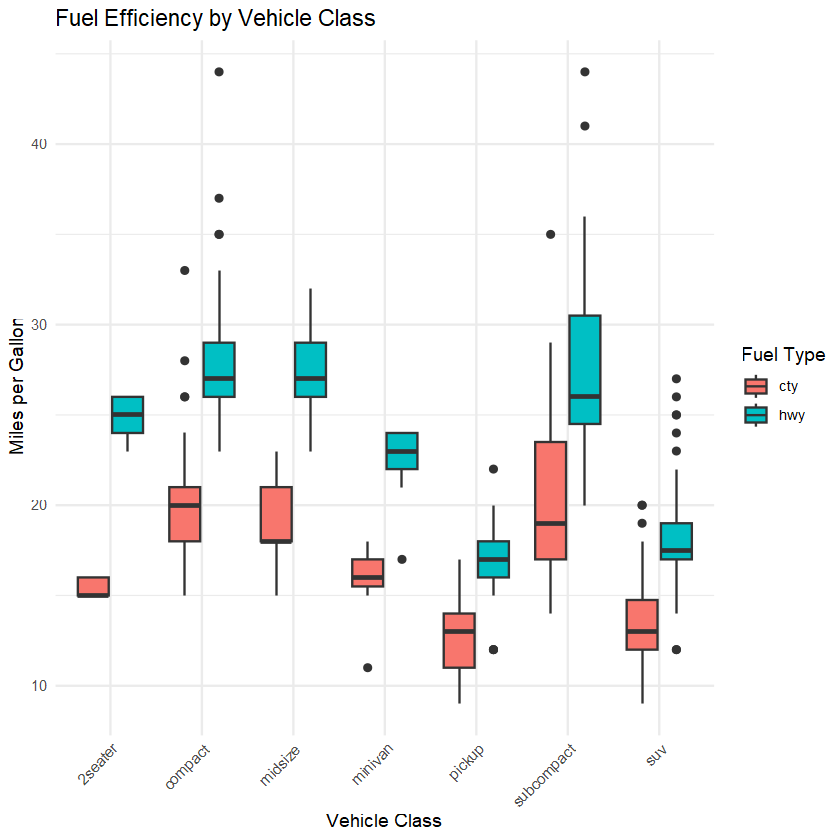

In [26]:
# 4. Visualize distributions
mpg %>%
  select(hwy, cty, class) %>%
  pivot_longer(
    cols = c(hwy, cty),
    names_to = "fuel_type",
    values_to = "mpg"
  ) %>%
  ggplot(aes(x = class, y = mpg, fill = fuel_type)) +
  geom_boxplot() +
  labs(
    title = "Fuel Efficiency by Vehicle Class",
    x = "Vehicle Class",
    y = "Miles per Gallon",
    fill = "Fuel Type"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [27]:
# 5. Correlation analysis
mpg %>%
  select(where(is.numeric)) %>%
  cor() %>%
  round(2)

,displ,year,cyl,cty,hwy
displ,1.00,0.15,0.93,-0.80,-0.77
year,0.15,1.00,0.12,-0.04,0.00
cyl,0.93,0.12,1.00,-0.81,-0.76
cty,-0.80,-0.04,-0.81,1.00,0.96
hwy,-0.77,0.00,-0.76,0.96,1.00


---

## Practice Exercises

### Exercise 1: Data Transformation
Using the `starwars` dataset:
1. Filter for characters with known height and mass
2. Calculate BMI for each character
3. Create a category: "Light" (BMI < 25) or "Heavy" (BMI >= 25)
4. Calculate the proportion in each category by species
5. Keep only species with more than 2 characters

In [28]:
# Your code here

### Exercise 2: Grouped Analysis
Using the `iris` dataset:
1. Calculate mean and SD for all measurements by Species
2. Find which measurement has the highest coefficient of variation (SD/mean) for each species
3. Create a visualization comparing the distributions

In [29]:
# Your code here

### Exercise 3: Complete Pipeline
Using the `mtcars` dataset:
1. Create categories for weight (light/medium/heavy based on tertiles)
2. Calculate mean mpg for each weight category and cylinder count
3. Create a visualization showing this relationship
4. Add a trend line
5. Save the plot with appropriate dimensions

In [30]:
# Your code here

## Summary

In this session, you learned:

**tidyverse Philosophy:**
- ✅ Understanding the tidyverse ecosystem
- ✅ Composing operations with pipes

**dplyr Core Verbs:**
- ✅ filter() - Selecting rows
- ✅ select() - Choosing columns
- ✅ mutate() - Creating/modifying columns
- ✅ arrange() - Sorting data
- ✅ summarize() - Calculating statistics

**Advanced Techniques:**
- ✅ group_by() for grouped operations
- ✅ across() for multiple columns
- ✅ case_when() for complex conditions
- ✅ Joining datasets

**tidyr:**
- ✅ pivot_longer() and pivot_wider()
- ✅ Tidy data principles

**Integration:**
- ✅ Combining dplyr with ggplot2
- ✅ Complete analysis pipelines
- ✅ Exploratory data analysis workflows

**Key Takeaway**: The tidyverse provides a consistent, powerful toolkit for modern data analysis in R. The pipe operator and verb-based functions make your code more readable and maintainable.

**Congratulations!** You've completed the Introduction to R course!

## Additional Resources

### Cheat Sheets:
- dplyr: https://github.com/rstudio/cheatsheets/raw/master/data-transformation.pdf
- tidyr: https://github.com/rstudio/cheatsheets/raw/master/tidyr.pdf
- ggplot2: https://github.com/rstudio/cheatsheets/raw/master/data-visualization.pdf

### Books:
- R for Data Science: https://r4ds.had.co.nz/
- tidyverse documentation: https://www.tidyverse.org/

### Community:
- RStudio Community: https://community.rstudio.com/
- R4DS Online Learning Community: https://www.rfordatasci.com/

In [31]:
sessionInfo()

R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=Portuguese_Portugal.utf8  LC_CTYPE=Portuguese_Portugal.utf8   
[3] LC_MONETARY=Portuguese_Portugal.utf8 LC_NUMERIC=C                        
[5] LC_TIME=Portuguese_Portugal.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lubridate_1.9.4 forcats_1.0.1   stringr_1.6.0   dplyr_1.1.4    
 [5] purrr_1.2.0     readr_2.1.6     tidyr_1.3.2     tibble_3.3.0   
 [9] ggplot2_4.0.1   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] Matrix_1.7-4       gtable_0.3.6       jsonlite_2.0.0     compiler_4.5.2    
 [5] crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1      dichromat_2.0-0.1 
 [9] splines_4.5.2      systemfonts_1.3.1  scales_1.4.0       textshaping_1.0

## Session Info

It's good practice to record your R session information at the end of your analysis. This helps with reproducibility by documenting:
- R version
- Operating system
- Loaded packages and their versions
- Other system details